In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
IMG_SIZE    = (224, 224) 
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 5

DATASET_DIR = "data/Soil types"

CLASS_NAMES = ["Black Soil", "Cinder Soil", "Laterite Soil", "Peat Soil", "Yellow Soil"]

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"\n  CUDA disponibil — {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("\n  Niciun GPU detectat — se foloseste CPU.")


  CUDA disponibil — NVIDIA GeForce RTX 3060 Ti


In [4]:
train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
    224,
    scale=(0.7, 1.0)
    ),        
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),       
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1), 
                                         
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


In [6]:
base_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=val_test_transform)
print(f"Clase detectate: {base_dataset.class_to_idx}\n")

indices = list(range(len(base_dataset)))
labels  = [base_dataset[i][1] for i in indices]

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=labels, random_state=RANDOM_SEED
)
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=RANDOM_SEED
)


idx_to_class = {v: k for k, v in base_dataset.class_to_idx.items()}

def print_split_details(split_name, split_indices, all_labels):
    split_labels = [all_labels[i] for i in split_indices]
    unique, counts = np.unique(split_labels, return_counts=True)
    details = "  ".join(f"{idx_to_class[c]}: {n}" for c, n in zip(unique, counts))
    print(f"  {split_name:5s} ({len(split_indices):4d} img)  {details}")

print("── Split stratificat 70/15/15 ────────────────────────────────────────")
print_split_details("train", train_idx, labels)
print_split_details("val",   val_idx,   labels)
print_split_details("test",  test_idx,  labels)
print()

Clase detectate: {'Black Soil': 0, 'Cinder Soil': 1, 'Laterite Soil': 2, 'Peat Soil': 3, 'Yellow Soil': 4}

── Split stratificat 70/15/15 ────────────────────────────────────────
  train ( 109 img)  Black Soil: 26  Cinder Soil: 21  Laterite Soil: 21  Peat Soil: 21  Yellow Soil: 20
  val   (  23 img)  Black Soil: 5  Cinder Soil: 4  Laterite Soil: 5  Peat Soil: 4  Yellow Soil: 5
  test  (  24 img)  Black Soil: 6  Cinder Soil: 5  Laterite Soil: 4  Peat Soil: 5  Yellow Soil: 4



In [7]:
from torch.utils.data import WeightedRandomSampler

train_labels  = [labels[i] for i in train_idx]
class_counts  = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in train_labels]

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

In [8]:
train_dataset = datasets.ImageFolder(root=DATASET_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=DATASET_DIR, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=DATASET_DIR, transform=val_test_transform)

train_loader = DataLoader(
    Subset(train_dataset, train_idx),
    batch_size=BATCH_SIZE,
    sampler = sampler,
    num_workers=2, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    Subset(val_dataset, val_idx),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)
test_loader = DataLoader(
    Subset(test_dataset, test_idx),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True, persistent_workers=True
)

In [9]:
weights = ResNet18_Weights.DEFAULT
model   = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


in_features = model.fc.in_features  # 512
model.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES),
)


model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parametri totali     : {total_params:,}")
print(f"Parametri antrenabili: {trainable_params:,} \n")


Parametri totali     : 11,309,125
Parametri antrenabili: 8,526,341 



In [10]:
optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-3},
])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

In [11]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0.0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [12]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_epoch    = 0

print(f"── Antrenare pe {DEVICE} — {EPOCHS} epoci (feature extraction) ──────")
print(f"{'Epoca':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8} | {'Checkpoint':>10}")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(model,  val_loader,   criterion, DEVICE)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)

    current_lr = scheduler.get_last_lr()[0]

    saved = ""
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), "best_resnet18_frozen.pth")
        saved = "✅ salvat"

    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | "
          f"{vl_loss:>8.4f} | {vl_acc:>6.2%} | {current_lr:>8.2e} | {saved}")

print(f"\nCel mai bun model: epoca {best_epoch} (val_loss={best_val_loss:.4f})")

── Antrenare pe cuda — 20 epoci (feature extraction) ──────
 Epoca | Train Loss | Train Acc | Val Loss | Val Acc |       LR | Checkpoint
--------------------------------------------------------------------------------
     1 |     1.5944 |   22.94% |   1.5359 | 30.43% | 9.94e-06 | ✅ salvat
     2 |     1.4495 |   45.87% |   1.4291 | 39.13% | 9.78e-06 | ✅ salvat
     3 |     1.2961 |   52.29% |   1.2848 | 52.17% | 9.51e-06 | ✅ salvat
     4 |     1.2092 |   55.96% |   1.1791 | 52.17% | 9.14e-06 | ✅ salvat
     5 |     1.0482 |   61.47% |   1.0746 | 60.87% | 8.68e-06 | ✅ salvat
     6 |     0.9474 |   76.15% |   0.9208 | 73.91% | 8.15e-06 | ✅ salvat
     7 |     0.9465 |   70.64% |   0.9751 | 69.57% | 7.54e-06 | 
     8 |     0.8887 |   78.90% |   0.8537 | 86.96% | 6.89e-06 | ✅ salvat
     9 |     0.8320 |   77.06% |   0.7999 | 78.26% | 6.20e-06 | ✅ salvat
    10 |     0.6998 |   92.66% |   0.7575 | 86.96% | 5.50e-06 | ✅ salvat
    11 |     0.6889 |   89.91% |   0.7569 | 86.96% | 4.80e-0

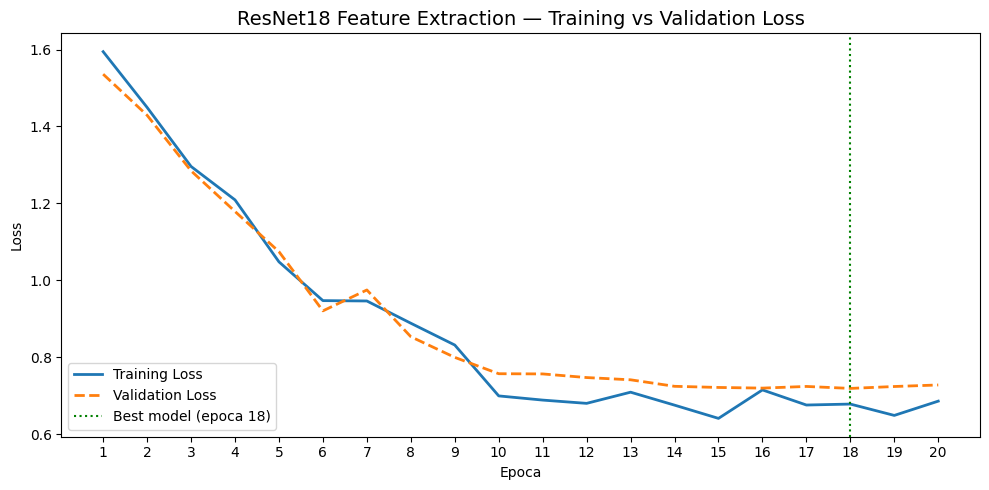

Grafic salvat: loss_curve_resnet18_frozen.png


In [13]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label="Training Loss",   linewidth=2)
plt.plot(epochs_range, val_losses,   label="Validation Loss", linewidth=2, linestyle="--")
plt.axvline(x=best_epoch, color="green", linestyle=":", linewidth=1.5,
            label=f"Best model (epoca {best_epoch})")
plt.title("ResNet18 Feature Extraction — Training vs Validation Loss", fontsize=14)
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve_resnet18_frozen.png", dpi=150)
plt.show()
print("Grafic salvat: loss_curve_resnet18_frozen.png")


Se incarca cel mai bun model (best_resnet18_frozen.pth)...

── Evaluare pe Test Set ──────────────────────
Test Accuracy : 0.7500
Test Loss     : 0.8818

Classification Report:
               precision    recall  f1-score   support

   Black Soil       0.67      1.00      0.80         6
  Cinder Soil       0.80      0.80      0.80         5
Laterite Soil       0.75      0.75      0.75         4
    Peat Soil       0.50      0.20      0.29         5
  Yellow Soil       1.00      1.00      1.00         4

     accuracy                           0.75        24
    macro avg       0.74      0.75      0.73        24
 weighted avg       0.73      0.75      0.72        24



C:\Users\Andrei\AppData\Local\Temp\ipykernel_18584\3023584899.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_resnet18_frozen.pth"

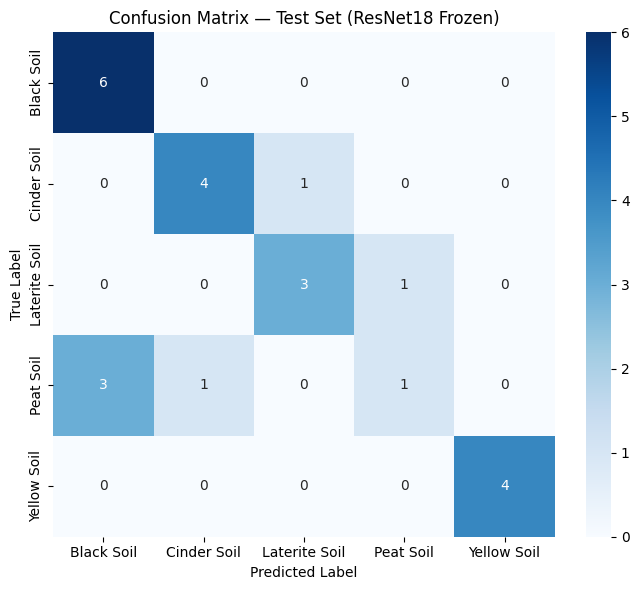

Confusion matrix salvata: confusion_matrix_resnet18_frozen.png


In [17]:
print("\nSe incarca cel mai bun model (best_resnet18_frozen.pth)...")
model.load_state_dict(torch.load("best_resnet18_frozen.pth", map_location=DEVICE))

test_loss, test_acc = eval_epoch(model, test_loader, criterion, DEVICE)
print(f"\n── Evaluare pe Test Set ──────────────────────")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Test Set (ResNet18 Frozen)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_resnet18_frozen.png", dpi=150)
plt.show()
print("Confusion matrix salvata: confusion_matrix_resnet18_frozen.png")